In [ ]:
# 05b — Robustness Sweeps (Scenario A) — QAOA (QUBO Baseline)

This notebook runs a **QAOA** solver on a **QUBO** formulation of Scenario A:

- We score each trial with an additive utility:

**wᵢ = benefit − λ_cost · cost − λ_safety · safety_penalty**

- We enforce an **exact-K** selection using a quadratic penalty:

**E(x) = − Σ wᵢ xᵢ  +  A · (Σ xᵢ − K)²**

We then sweep robustness across:
- `K` (portfolio size)
- `λ_cost`, `λ_safety` (trade-off weights)
- `noise_sigma` (optional multiplicative perturbation on benefit/cost/safety)
- `seed` (repeatability across perturbations)

Artifacts are written with a QAOA-specific prefix to avoid collisions:
- `data/results/05b_qaoa_robustness_sweep_summary.csv`
- `data/results/05b_qaoa_top_configs_selected_trials.csv`
- `data/results/05b_qaoa_top_config_table.csv`
- `outputs/figures/05b_qaoa_objective_heatmap.png`
- `outputs/figures/05b_qaoa_jaccard_vs_baseline.png`

Notes:
- QAOA runtime grows quickly with qubit count. This notebook supports a configurable **candidate pool size** (`POOL_SIZE`)
  to limit qubits during sweeps.
- Backend: prefers Aer if available; otherwise falls back to Statevector sampling (recommended for small qubit counts).


In [4]:
# ============================================================
# Cell 1 — Setup: imports, paths, and output directories
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Reproducibility ---
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# --- Project directories ---
DATA_DIR = Path("data")
RESULTS_DIR = DATA_DIR / "results"
SCENARIOS_DIR = DATA_DIR / "scenarios"
FIG_DIR = Path("outputs") / "figures"

# Create output directories if missing
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Input files (Scenario A) ---
# Prefer the Scenario A candidate file if present; otherwise fall back to the 03e artifact.
PATH_SCENARIO_A_TRIALS = SCENARIOS_DIR / "scenario_A_trials.csv"
PATH_QAOA_SELECTED     = RESULTS_DIR / "03e_scenario_A_selected_trials.csv"

# --- Outputs (QAOA-specific prefix to avoid collisions) ---
OUT_PREFIX = "05b_qaoa"
PATH_SWEEP_SUMMARY = RESULTS_DIR / f"{OUT_PREFIX}_robustness_sweep_summary.csv"
PATH_TOP_SELECTED  = RESULTS_DIR / f"{OUT_PREFIX}_top_configs_selected_trials.csv"
PATH_TOP_TABLE     = RESULTS_DIR / f"{OUT_PREFIX}_top_config_table.csv"
PATH_FIG_HEATMAP   = FIG_DIR     / f"{OUT_PREFIX}_objective_heatmap.png"
PATH_FIG_JACCARD   = FIG_DIR     / f"{OUT_PREFIX}_jaccard_vs_baseline.png"

# --- Quick existence checks (keeps notebook friendly) ---
if not PATH_SCENARIO_A_TRIALS.exists() and not PATH_QAOA_SELECTED.exists():
    raise FileNotFoundError(
        "Missing Scenario A candidates.\n"
        f"Expected one of:\n"
        f"  - {PATH_SCENARIO_A_TRIALS}\n"
        f"  - {PATH_QAOA_SELECTED}\n"
        "Fix: generate Scenario A candidates or update paths in Cell 1."
    )

print("OK: Paths initialized.")
print("Results dir:", RESULTS_DIR.resolve())
print("Figures dir:", FIG_DIR.resolve())
print("Candidate source preference:", PATH_SCENARIO_A_TRIALS, "-> fallback:", PATH_QAOA_SELECTED)


OK: Paths initialized.
Results dir: /home/parallels/projects/quantum-clinical-trial-optimization/data/results
Figures dir: /home/parallels/projects/quantum-clinical-trial-optimization/outputs/figures
Candidate source preference: data/scenarios/scenario_A_trials.csv -> fallback: data/results/03e_scenario_A_selected_trials.csv


In [ ]:
### What Cell 1 Just Did

- Imported core libraries and set a global random seed for repeatability.
- Defined input and output paths for Scenario A and created output directories.
- Ensured we have at least one valid Scenario A candidate source to load.
- Set QAOA-specific output filenames (`05b_qaoa_*`) so this notebook won’t overwrite other Phase 5 artifacts.


In [5]:
# ============================================================
# Cell 2 — Load Scenario A candidates and standardize columns
# ============================================================

# --- Load from preferred source ---
if PATH_SCENARIO_A_TRIALS.exists():
    candidates = pd.read_csv(PATH_SCENARIO_A_TRIALS)
    source_path = PATH_SCENARIO_A_TRIALS
else:
    candidates = pd.read_csv(PATH_QAOA_SELECTED)
    source_path = PATH_QAOA_SELECTED

print(f"Loaded candidates from: {source_path}")
print("Raw shape:", candidates.shape)

# --- Standardize trial identifier to `nct_id` ---
id_candidates = ["nct_id", "NCT_ID", "trial_id", "TrialID", "id"]
found_id = next((c for c in id_candidates if c in candidates.columns), None)
if found_id is None:
    raise ValueError(
        "No trial identifier column found.\n"
        f"Expected one of: {id_candidates}\n"
        f"Columns present: {list(candidates.columns)}"
    )
if found_id != "nct_id":
    candidates = candidates.rename(columns={found_id: "nct_id"})

# --- Standardize scoring components into raw columns ---
# We require three non-negative components:
#   _benefit_raw, _cost_raw, _safety_raw
#
# Your Scenario A candidate file includes:
#   - benefit_score
#   - estimated_trial_cost
#   - enrollment_feasibility_score
#
# We'll map:
#   benefit  <- benefit_score (higher is better)
#   cost     <- estimated_trial_cost (higher is worse)
#   safety   <- feasibility_penalty derived from enrollment_feasibility_score (higher is worse)

benefit_candidates = ["_benefit_raw", "benefit_raw", "benefit", "Benefit", "utility", "objective_benefit", "benefit_score"]
cost_candidates    = ["_cost_raw", "cost_raw", "cost", "Cost", "objective_cost", "estimated_trial_cost"]
safety_candidates  = ["_safety_raw", "safety_raw", "safety", "Safety", "risk", "objective_safety", "safety_score"]

def first_present(cols):
    return next((c for c in cols if c in candidates.columns), None)

bcol = first_present(benefit_candidates)
ccol = first_present(cost_candidates)
scol = first_present(safety_candidates)

# Rename benefit/cost into standardized raw columns
rename_map = {}
if bcol is not None and bcol != "_benefit_raw":
    rename_map[bcol] = "_benefit_raw"
if ccol is not None and ccol != "_cost_raw":
    rename_map[ccol] = "_cost_raw"
candidates = candidates.rename(columns=rename_map)

# Ensure benefit/cost exist after mapping
if "_benefit_raw" not in candidates.columns or "_cost_raw" not in candidates.columns:
    raise ValueError(
        "Missing required benefit/cost columns even after mapping.\n"
        f"Found benefit col: {bcol}, cost col: {ccol}\n"
        f"Columns present: {list(candidates.columns)}"
    )

# If safety/risk column doesn't exist, derive a penalty from feasibility
if "_safety_raw" not in candidates.columns:
    if "enrollment_feasibility_score" not in candidates.columns:
        candidates["_safety_raw"] = 0.0
        print("Warning: No safety/risk or feasibility column found. Setting _safety_raw = 0.0 for all rows.")
    else:
        feas = pd.to_numeric(candidates["enrollment_feasibility_score"], errors="coerce")
        if feas.isna().any():
            n_bad = int(feas.isna().sum())
            raise ValueError(f"enrollment_feasibility_score contains {n_bad} NaNs after numeric coercion. Fix upstream.")
        candidates["_safety_raw"] = (float(feas.max()) - feas).clip(lower=0.0)
        print("Derived _safety_raw from enrollment_feasibility_score as (max(feas) - feas).")
else:
    if scol is not None and scol != "_safety_raw" and scol in candidates.columns:
        candidates = candidates.rename(columns={scol: "_safety_raw"})

# Coerce to numeric, forbid NaNs, and clamp to non-negative
for col in ["_benefit_raw", "_cost_raw", "_safety_raw"]:
    candidates[col] = pd.to_numeric(candidates[col], errors="coerce")
    if candidates[col].isna().any():
        n_bad = int(candidates[col].isna().sum())
        raise ValueError(f"{col} contains {n_bad} NaNs after numeric coercion. Fix upstream.")
    candidates[col] = candidates[col].clip(lower=0.0)

# Working copies (may be perturbed during sweeps)
candidates["_benefit"] = candidates["_benefit_raw"].astype(float)
candidates["_cost"]    = candidates["_cost_raw"].astype(float)
candidates["_safety"]  = candidates["_safety_raw"].astype(float)

# One row per trial; stable ordering for deterministic mapping
candidates = (
    candidates.drop_duplicates(subset=["nct_id"])
              .sort_values("nct_id")
              .reset_index(drop=True)
)

print("Standardized preview:")
display(candidates[["nct_id", "_benefit_raw", "_cost_raw", "_safety_raw"]].head(10))
print("Final candidate shape:", candidates.shape)


Loaded candidates from: data/scenarios/scenario_A_trials.csv
Raw shape: (16672, 13)
Derived _safety_raw from enrollment_feasibility_score as (max(feas) - feas).
Standardized preview:


,nct_id,_benefit_raw,_cost_raw,_safety_raw
0,NCT00002462,0.8,4.0,0.0
1,NCT00003042,0.6,2.0,0.0
2,NCT00003641,0.8,4.0,0.0
3,NCT00005584,0.8,4.0,0.0
4,NCT00006721,0.8,4.0,0.0
5,NCT00007150,0.6,2.0,0.0
6,NCT00018057,0.6,2.0,0.0
7,NCT00026312,0.8,4.0,0.0
8,NCT00044304,0.6,2.0,0.0
9,NCT00070499,0.6,2.0,0.0


Final candidate shape: (16672, 17)


In [ ]:
### What Cell 2 Just Did

- Loaded Scenario A candidate trials from `data/scenarios/scenario_A_trials.csv` (falling back to `data/results/03e_scenario_A_selected_trials.csv` if needed).
- Standardized the trial identifier to `nct_id`.
- Mapped your available scoring columns into an additive “benefit/cost/safety-penalty” contract:
  - `_benefit_raw` ← `benefit_score`
  - `_cost_raw` ← `estimated_trial_cost`
  - `_safety_raw` derived from `enrollment_feasibility_score` as `(max(feasibility) − feasibility)` so higher values represent a larger penalty.
- Enforced numeric types, disallowed NaNs in the scoring components, clamped to non-negative values, and created working copies (`_benefit`, `_cost`, `_safety`) for perturbation in later robustness sweeps.
- Deduplicated on `nct_id` and applied a stable sort for deterministic candidate-to-qubit mapping.


In [6]:
# ============================================================
# Cell 3 — QAOA (QUBO) utilities: scoring, QUBO energy, circuit, sampling
# ============================================================

from dataclasses import dataclass

@dataclass(frozen=True)
class Config:
    K: int
    lambda_cost: float
    lambda_safety: float
    noise_sigma: float
    seed: int
    pool_size: int
    p: int
    penalty_A: float
    shots: int

def compute_weights(df: pd.DataFrame, lc: float, ls: float) -> np.ndarray:
    """
    w_i = benefit - lc*cost - ls*safety_penalty
    """
    return (df["_benefit"].to_numpy(float)
            - lc * df["_cost"].to_numpy(float)
            - ls * df["_safety"].to_numpy(float))

def perturb_components(df: pd.DataFrame, noise_sigma: float, seed: int) -> pd.DataFrame:
    """
    Apply multiplicative lognormal noise to raw components and write into
    working columns _benefit/_cost/_safety.
    """
    out = df.copy()
    if noise_sigma <= 0.0:
        out["_benefit"] = out["_benefit_raw"].astype(float)
        out["_cost"]    = out["_cost_raw"].astype(float)
        out["_safety"]  = out["_safety_raw"].astype(float)
        return out

    rng = np.random.default_rng(seed)
    f_b = rng.lognormal(mean=0.0, sigma=noise_sigma, size=len(out))
    f_c = rng.lognormal(mean=0.0, sigma=noise_sigma, size=len(out))
    f_s = rng.lognormal(mean=0.0, sigma=noise_sigma, size=len(out))

    out["_benefit"] = np.clip(out["_benefit_raw"].to_numpy(float) * f_b, 0.0, None)
    out["_cost"]    = np.clip(out["_cost_raw"].to_numpy(float)    * f_c, 0.0, None)
    out["_safety"]  = np.clip(out["_safety_raw"].to_numpy(float)  * f_s, 0.0, None)
    return out

def pick_candidate_pool(df: pd.DataFrame, w: np.ndarray, pool_size: int) -> pd.DataFrame:
    """
    Choose a pool of candidates to fit the number of qubits.
    Default: top pool_size by weight w (stable tie-break by nct_id).
    """
    work = df.copy()
    work["_w"] = w
    work = work.sort_values(["_w", "nct_id"], ascending=[False, True]).head(pool_size).reset_index(drop=True)
    return work.drop(columns=["_w"])

def bitstring_to_x(bitstr: str, n: int) -> np.ndarray:
    """
    Convert Qiskit measurement bitstring to x in {0,1}^n.
    Qiskit returns strings with qubit-0 as the RIGHTMOST bit.
    We reverse to align index 0 with qubit 0 / candidate 0.
    """
    b = bitstr.strip()
    b = b.replace(" ", "")
    if len(b) != n:
        # Defensive: pad/truncate if needed
        if len(b) < n:
            b = b.zfill(n)
        else:
            b = b[-n:]
    bits = list(reversed(b))
    return np.array([1 if ch == "1" else 0 for ch in bits], dtype=int)

def energy_qubo(x: np.ndarray, w: np.ndarray, K: int, A: float) -> float:
    """
    QUBO energy:
      E(x) = -sum_i w_i x_i + A * (sum_i x_i - K)^2
    """
    s = int(x.sum())
    return float(-np.dot(w, x) + A * (s - K) * (s - K))

def portfolio_metrics_from_x(x: np.ndarray, df_pool: pd.DataFrame, lc: float, ls: float) -> dict:
    """
    Compute metrics on the selected subset defined by x.
    """
    sel = df_pool.iloc[np.where(x == 1)[0]].copy()
    total_benefit = float(sel["_benefit"].sum()) if not sel.empty else 0.0
    total_cost    = float(sel["_cost"].sum())    if not sel.empty else 0.0
    total_safety  = float(sel["_safety"].sum())  if not sel.empty else 0.0
    objective = total_benefit - (lc * total_cost) - (ls * total_safety)
    return {
        "selected_n": int(len(sel)),
        "total_benefit": total_benefit,
        "total_cost": total_cost,
        "total_safety": total_safety,
        "objective": float(objective),
    }

def jaccard(a_ids, b_ids) -> float:
    a = set(a_ids)
    b = set(b_ids)
    if not a and not b:
        return 1.0
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)

def config_id(cfg: Config) -> str:
    return (f"K{cfg.K}_lc{cfg.lambda_cost:.4g}_ls{cfg.lambda_safety:.4g}_"
            f"sig{cfg.noise_sigma:.3g}_seed{cfg.seed}_pool{cfg.pool_size}_p{cfg.p}_A{cfg.penalty_A:.3g}_sh{cfg.shots}")

# ------------------------------------------------------------
# QAOA circuit construction (supports p layers)
#   E(x) = -w·x + A (sum x - K)^2  -> convert to Ising (Z, ZZ)
#
# For this specific QUBO, coefficients simplify to:
#   h_i = w_i/2 - A*(N - 2K)/2
#   J_ij = A/2  for all i<j
#
# Cost unitary: exp(-i gamma (Σ h_i Z_i + Σ J_ij Z_i Z_j))
# Mixer: exp(-i beta Σ X_i)
# ------------------------------------------------------------

def _try_import_qiskit():
    try:
        from qiskit import QuantumCircuit
        from qiskit.quantum_info import Statevector
        return True
    except Exception:
        return False

if not _try_import_qiskit():
    raise ImportError(
        "Qiskit is not available in this environment.\n"
        "Fix: install qiskit (and optionally qiskit-aer) in your active environment."
    )

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# Optional Aer backend (preferred for sampling)
HAVE_AER = False
try:
    from qiskit_aer import AerSimulator
    HAVE_AER = True
except Exception:
    HAVE_AER = False

print("Qiskit available:", True)
print("Aer available:", HAVE_AER)

def build_qaoa_circuit(w: np.ndarray, K: int, A: float, gammas: np.ndarray, betas: np.ndarray) -> QuantumCircuit:
    """
    Build a QAOA circuit for the Ising form induced by the specific exact-K QUBO.
    """
    n = len(w)
    p = len(gammas)
    assert len(betas) == p

    # Ising coefficients (for Z-basis)
    h = (w / 2.0) - (A * (n - 2 * K) / 2.0)
    J = (A / 2.0)

    qc = QuantumCircuit(n, n)

    # Initial state: uniform superposition
    qc.h(range(n))

    for layer in range(p):
        gamma = float(gammas[layer])
        beta = float(betas[layer])

        # Cost unitaries: Z terms
        for i in range(n):
            # exp(-i gamma h_i Z_i) == RZ(2*gamma*h_i)
            qc.rz(2.0 * gamma * float(h[i]), i)

        # Cost unitaries: ZZ terms for all pairs (dense)
        # exp(-i gamma J Z_i Z_j) == RZZ(2*gamma*J)
        theta_zz = 2.0 * gamma * float(J)
        if abs(theta_zz) > 0:
            for i in range(n):
                for j in range(i + 1, n):
                    qc.rzz(theta_zz, i, j)

        # Mixer: RX on all qubits
        for i in range(n):
            qc.rx(2.0 * beta, i)

    # Measure
    qc.measure(range(n), range(n))
    return qc

def sample_bitstrings(qc: QuantumCircuit, shots: int, seed: int) -> dict:
    """
    Return counts dict: {bitstring: count}
    """
    if HAVE_AER:
        sim = AerSimulator(seed_simulator=seed)
        job = sim.run(qc, shots=shots)
        result = job.result()
        return result.get_counts()
    else:
        # Statevector fallback (no Aer). Recommended only for small n.
        qc_nom = qc.remove_final_measurements(inplace=False)
        sv = Statevector.from_instruction(qc_nom)
        probs = sv.probabilities()

        rng = np.random.default_rng(seed)
        idx = rng.choice(len(probs), size=shots, p=probs)

        # Convert sampled basis index -> bitstring with n bits (big-endian)
        n = qc.num_qubits
        counts = {}
        for k in idx:
            b = format(int(k), f"0{n}b")  # big-endian string
            # emulate qiskit get_counts output format (bitstring as displayed)
            counts[b] = counts.get(b, 0) + 1
        return counts

def choose_best_from_counts(counts: dict, w: np.ndarray, K: int, A: float) -> tuple[str, float]:
    """
    Pick the best bitstring by minimum QUBO energy from sampled counts.
    Returns (best_bitstring, best_energy).
    """
    n = len(w)
    best_b = None
    best_E = None
    for b, c in counts.items():
        x = bitstring_to_x(b, n)
        E = energy_qubo(x, w, K, A)
        if (best_E is None) or (E < best_E):
            best_E = E
            best_b = b
    return best_b, float(best_E)

def grid_search_qaoa_params(w: np.ndarray, K: int, A: float, p: int, shots: int, seed: int,
                           gamma_grid=None, beta_grid=None) -> tuple[np.ndarray, np.ndarray, str, float]:
    """
    Simple brute-force grid search for p=1 (recommended default for sweeps).
    For p>1, uses a small random search.
    Returns (gammas, betas, best_bitstring, best_energy).
    """
    n = len(w)

    if p == 1:
        if gamma_grid is None:
            gamma_grid = np.linspace(0.1, 1.8, 10)
        if beta_grid is None:
            beta_grid = np.linspace(0.1, 1.8, 10)

        best = None
        best_pack = None

        for gamma in gamma_grid:
            for beta in beta_grid:
                qc = build_qaoa_circuit(w, K, A, np.array([gamma]), np.array([beta]))
                counts = sample_bitstrings(qc, shots=shots, seed=seed)
                b, E = choose_best_from_counts(counts, w, K, A)
                if (best is None) or (E < best):
                    best = E
                    best_pack = (np.array([gamma]), np.array([beta]), b, E)

        return best_pack
    else:
        # Light random search for p>1 (kept small to avoid runaway runtime)
        rng = np.random.default_rng(seed)
        N_TRIES = 20
        best = None
        best_pack = None

        for _ in range(N_TRIES):
            gammas = rng.uniform(0.1, 1.8, size=p)
            betas  = rng.uniform(0.1, 1.8, size=p)
            qc = build_qaoa_circuit(w, K, A, gammas, betas)
            counts = sample_bitstrings(qc, shots=shots, seed=seed)
            b, E = choose_best_from_counts(counts, w, K, A)
            if (best is None) or (E < best):
                best = E
                best_pack = (gammas, betas, b, E)

        return best_pack

print("OK: QAOA/QUBO utilities defined.")


Qiskit available: True
Aer available: False
OK: QAOA/QUBO utilities defined.


In [ ]:
### What Cell 3 Just Did

- Defined the additive trial weight function used by both greedy and QAOA: `w = benefit − λ_cost·cost − λ_safety·safety_penalty`.
- Defined the exact-K QUBO energy function `E(x) = −w·x + A(Σx − K)²`, plus decoding helpers and metrics.
- Implemented a QAOA circuit for the induced dense Ising model (Z and ZZ terms) and a sampling backend:
  - Uses Aer if available for sampling
  - Falls back to Statevector-based sampling if Aer is not installed (recommended only for small qubit counts)
- Implemented a simple parameter search:
  - Grid search for p=1 (fastest and most sweep-friendly)
  - Small random search for p>1 (kept intentionally small for runtime safety)


In [9]:
# ============================================================
# Cell 4 — Robustness sweep runner (QAOA): grid + artifacts (Aer-free + FIXED POOL)
# ============================================================

# --- QAOA sweep controls ---
# With Aer unavailable, we rely on Statevector sampling. Keep POOL_SIZE small.
POOL_SIZE = 12          # qubits / candidates in the pool (keep <= 14-ish without Aer)
P_LAYERS  = 1           # use p=1 for sweep feasibility
SHOTS     = 128         # keep modest without Aer
PENALTY_A = 10.0        # penalty strength enforcing exact-K

# --- Sweep grid (K must be <= POOL_SIZE) ---
K_values = [6, 9, 12]   # you can start with [6] and expand
lambda_cost_values = [0.5, 1.0, 2.0]
lambda_safety_values = [0.5, 1.0, 2.0]

# Robustness perturbations
noise_sigmas = [0.0, 0.05, 0.10]
seeds = [0, 1, 2]       # start smaller without Aer; expand later

# --- Parameter search grid (p=1) ---
# 5x5 grid is 25 circuit evals per config (vs 100 with a 10x10 grid).
GAMMA_GRID = np.linspace(0.2, 1.6, 5)
BETA_GRID  = np.linspace(0.2, 1.6, 5)

# --- Checkpointing / progress ---
CHECKPOINT_EVERY = 5
CHECKPOINT_PATH = RESULTS_DIR / f"{OUT_PREFIX}_checkpoint_partial.csv"

# Baseline config used for stability comparisons (must be within grid)
BASELINE = Config(
    K=9,
    lambda_cost=1.0,
    lambda_safety=1.0,
    noise_sigma=0.0,
    seed=0,
    pool_size=POOL_SIZE,
    p=P_LAYERS,
    penalty_A=PENALTY_A,
    shots=SHOTS
)

# --- Safety checks ---
if max(K_values) > POOL_SIZE:
    raise ValueError(
        f"Invalid settings: max(K_values)={max(K_values)} exceeds POOL_SIZE={POOL_SIZE}.\n"
        "Fix: reduce K_values or increase POOL_SIZE."
    )

print("Aer available:", HAVE_AER)
if not HAVE_AER:
    print("Running in Aer-free mode (Statevector sampling). Keep POOL_SIZE small.")
if P_LAYERS != 1:
    raise ValueError("This Aer-free cell is tuned for p=1. Set P_LAYERS = 1.")

def run_qaoa_once_fixed_pool(df_pool_fixed: pd.DataFrame, cfg: Config) -> dict:
    """
    Single QAOA solve for a configuration using a FIXED pool (same qubits/candidates for all configs).
    Returns a dict with:
      - selected_df
      - selected_ids
      - metrics
      - best_bitstring/best_energy/gammas/betas
    """
    # 1) weights on the fixed pool (pool is already perturbed upstream in the sweep loop when needed)
    w_pool = compute_weights(df_pool_fixed, cfg.lambda_cost, cfg.lambda_safety)

    # 2) parameter search -> best sampled bitstring
    gammas, betas, best_b, best_E = grid_search_qaoa_params(
        w=w_pool,
        K=cfg.K,
        A=cfg.penalty_A,
        p=cfg.p,
        shots=cfg.shots,
        seed=cfg.seed,
        gamma_grid=GAMMA_GRID,
        beta_grid=BETA_GRID
    )

    # 3) decode
    x = bitstring_to_x(best_b, len(w_pool))

    # 4) metrics + selection
    mets = portfolio_metrics_from_x(x, df_pool_fixed, cfg.lambda_cost, cfg.lambda_safety)
    selected_df = df_pool_fixed.iloc[np.where(x == 1)[0]].copy()
    selected_ids = selected_df["nct_id"].tolist()

    return {
        "selected_df": selected_df,
        "selected_ids": selected_ids,
        "metrics": mets,
        "best_bitstring": best_b,
        "best_energy": float(best_E),
        "gammas": gammas,
        "betas": betas,
    }

# ------------------------------------------------------------
# FIXED POOL: Build it once using baseline weights (no noise)
#   This makes Jaccard comparisons meaningful across configs.
# ------------------------------------------------------------
df_for_pool = perturb_components(candidates, noise_sigma=0.0, seed=0)
w_for_pool = compute_weights(df_for_pool, BASELINE.lambda_cost, BASELINE.lambda_safety)

DF_POOL_FIXED = pick_candidate_pool(df_for_pool, w_for_pool, POOL_SIZE).copy()

# Re-attach working columns in case pick_candidate_pool dropped anything (it shouldn't)
# (defensive, harmless)
for col in ["_benefit_raw", "_cost_raw", "_safety_raw", "_benefit", "_cost", "_safety"]:
    if col not in DF_POOL_FIXED.columns and col in df_for_pool.columns:
        DF_POOL_FIXED[col] = df_for_pool.loc[DF_POOL_FIXED.index, col].values

print("Fixed pool built.")
print("Fixed pool size:", DF_POOL_FIXED.shape[0])
print("Fixed pool preview:")
display(DF_POOL_FIXED[["nct_id", "_benefit", "_cost", "_safety"]].head(5))

# --- Establish baseline selection set (QAOA baseline) ---
baseline_run = run_qaoa_once_fixed_pool(DF_POOL_FIXED, BASELINE)
baseline_set = set(baseline_run["selected_ids"])

print("Baseline config:", BASELINE)
print("Baseline selected_n:", len(baseline_set))

# Quick decode sanity check (should be close to K due to penalty)
baseline_x = bitstring_to_x(baseline_run["best_bitstring"], POOL_SIZE)
print("Baseline bitstring:", baseline_run["best_bitstring"])
print("Baseline sum(x):", int(baseline_x.sum()), " (target K =", BASELINE.K, ")")

# --- Run sweep ---
rows = []

TOTAL = len(K_values) * len(lambda_cost_values) * len(lambda_safety_values) * len(noise_sigmas) * len(seeds)
done = 0

for K in K_values:
    for lc in lambda_cost_values:
        for ls in lambda_safety_values:
            for sig in noise_sigmas:
                for seed in seeds:
                    cfg = Config(
                        K=K,
                        lambda_cost=lc,
                        lambda_safety=ls,
                        noise_sigma=sig,
                        seed=seed,
                        pool_size=POOL_SIZE,
                        p=P_LAYERS,
                        penalty_A=PENALTY_A,
                        shots=SHOTS
                    )

                    # Perturb the FIXED pool rows (not the full candidate set). Keeps qubits/candidates identical.
                    df_pool_run = perturb_components(DF_POOL_FIXED, noise_sigma=cfg.noise_sigma, seed=cfg.seed)

                    run = run_qaoa_once_fixed_pool(df_pool_run, cfg)
                    sel_ids = run["selected_ids"]
                    jac = jaccard(sel_ids, baseline_set)
                    mets = run["metrics"]

                    rows.append({
                        "config_id": config_id(cfg),
                        "K": cfg.K,
                        "lambda_cost": cfg.lambda_cost,
                        "lambda_safety": cfg.lambda_safety,
                        "noise_sigma": cfg.noise_sigma,
                        "seed": cfg.seed,
                        "pool_size": cfg.pool_size,
                        "p": cfg.p,
                        "penalty_A": cfg.penalty_A,
                        "shots": cfg.shots,
                        "jaccard_vs_baseline": float(jac),
                        "best_energy": float(run["best_energy"]),
                        "best_bitstring": str(run["best_bitstring"]),
                        "gamma_0": float(run["gammas"][0]) if len(run["gammas"]) > 0 else np.nan,
                        "beta_0": float(run["betas"][0]) if len(run["betas"]) > 0 else np.nan,
                        **mets,
                    })

                    done += 1
                    if done % CHECKPOINT_EVERY == 0:
                        pd.DataFrame(rows).to_csv(CHECKPOINT_PATH, index=False)
                        print(f"Progress: {done}/{TOTAL} configs complete (checkpoint saved)")

# --- Finalize summary dataframe ---
summary_df = pd.DataFrame(rows)

# Normalize objective across the sweep for comparability
obj_min = float(summary_df["objective"].min())
obj_max = float(summary_df["objective"].max())
den = (obj_max - obj_min) if (obj_max > obj_min) else 1.0
summary_df["objective_norm"] = (summary_df["objective"] - obj_min) / den

# Save sweep summary
summary_df.to_csv(PATH_SWEEP_SUMMARY, index=False)
print("Wrote:", PATH_SWEEP_SUMMARY)

# Aggregate per configuration (mean/std across seeds)
group_cols = ["K", "lambda_cost", "lambda_safety", "noise_sigma", "pool_size", "p", "penalty_A", "shots"]
agg = (
    summary_df.groupby(group_cols, as_index=False)
    .agg(
        objective_mean=("objective", "mean"),
        objective_std=("objective", "std"),
        objective_norm_mean=("objective_norm", "mean"),
        jaccard_mean=("jaccard_vs_baseline", "mean"),
        jaccard_std=("jaccard_vs_baseline", "std"),
        n_runs=("objective", "size"),
    )
)

# Choose top configs by objective_norm_mean, break ties by stability
TOP_N = 10
top_configs = (
    agg.sort_values(["objective_norm_mean", "jaccard_mean"], ascending=[False, False])
       .head(TOP_N)
       .reset_index(drop=True)
)

top_configs.to_csv(PATH_TOP_TABLE, index=False)
print("Wrote:", PATH_TOP_TABLE)

# Materialize selected trials for each top config (seed=0 for reproducibility)
selected_trials_blocks = []
for _, r in top_configs.iterrows():
    cfg0 = Config(
        K=int(r["K"]),
        lambda_cost=float(r["lambda_cost"]),
        lambda_safety=float(r["lambda_safety"]),
        noise_sigma=float(r["noise_sigma"]),
        seed=0,
        pool_size=int(r["pool_size"]),
        p=int(r["p"]),
        penalty_A=float(r["penalty_A"]),
        shots=int(r["shots"]),
    )
    df_pool0 = perturb_components(DF_POOL_FIXED, noise_sigma=cfg0.noise_sigma, seed=cfg0.seed)
    run0 = run_qaoa_once_fixed_pool(df_pool0, cfg0)
    sel0 = run0["selected_df"].copy()

    sel0["config_id"] = config_id(cfg0)
    sel0["K"] = cfg0.K
    sel0["lambda_cost"] = cfg0.lambda_cost
    sel0["lambda_safety"] = cfg0.lambda_safety
    sel0["noise_sigma"] = cfg0.noise_sigma
    sel0["seed"] = cfg0.seed
    sel0["pool_size"] = cfg0.pool_size
    sel0["p"] = cfg0.p
    sel0["penalty_A"] = cfg0.penalty_A
    sel0["shots"] = cfg0.shots

    selected_trials_blocks.append(sel0)

top_selected_trials_df = pd.concat(selected_trials_blocks, ignore_index=True) if selected_trials_blocks else pd.DataFrame()
top_selected_trials_df.to_csv(PATH_TOP_SELECTED, index=False)
print("Wrote:", PATH_TOP_SELECTED)

display(top_configs)


Aer available: False
Running in Aer-free mode (Statevector sampling). Keep POOL_SIZE small.
Fixed pool built.
Fixed pool size: 12
Fixed pool preview:


,nct_id,_benefit,_cost,_safety
0,NCT00003042,0.6,2.0,0.0
1,NCT00007150,0.6,2.0,0.0
2,NCT00018057,0.6,2.0,0.0
3,NCT00044304,0.6,2.0,0.0
4,NCT00070499,0.6,2.0,0.0


Baseline config: Config(K=9, lambda_cost=1.0, lambda_safety=1.0, noise_sigma=0.0, seed=0, pool_size=12, p=1, penalty_A=10.0, shots=128)
Baseline selected_n: 9
Baseline bitstring: 101111111100
Baseline sum(x): 9  (target K = 9 )
Progress: 5/243 configs complete (checkpoint saved)
Progress: 10/243 configs complete (checkpoint saved)
Progress: 15/243 configs complete (checkpoint saved)
Progress: 20/243 configs complete (checkpoint saved)
Progress: 25/243 configs complete (checkpoint saved)
Progress: 30/243 configs complete (checkpoint saved)
Progress: 35/243 configs complete (checkpoint saved)
Progress: 40/243 configs complete (checkpoint saved)
Progress: 45/243 configs complete (checkpoint saved)
Progress: 50/243 configs complete (checkpoint saved)
Progress: 55/243 configs complete (checkpoint saved)
Progress: 60/243 configs complete (checkpoint saved)
Progress: 65/243 configs complete (checkpoint saved)
Progress: 70/243 configs complete (checkpoint saved)
Progress: 75/243 configs comple

,K,lambda_cost,lambda_safety,noise_sigma,pool_size,p,penalty_A,shots,objective_mean,objective_std,objective_norm_mean,jaccard_mean,jaccard_std,n_runs
0,6,0.5,0.5,0.10,12,1,10.0,128,-1.951298,0.106528,0.996850,0.363636,0.00000,3
1,6,0.5,1.0,0.10,12,1,10.0,128,-1.951298,0.106528,0.996850,0.363636,0.00000,3
2,6,0.5,2.0,0.10,12,1,10.0,128,-1.951298,0.106528,0.996850,0.363636,0.00000,3
3,6,0.5,0.5,0.05,12,1,10.0,128,-2.181031,0.062375,0.990965,0.409091,0.07873,3
4,6,0.5,1.0,0.05,12,1,10.0,128,-2.181031,0.062375,0.990965,0.409091,0.07873,3
5,6,0.5,2.0,0.05,12,1,10.0,128,-2.181031,0.062375,0.990965,0.409091,0.07873,3
6,6,0.5,0.5,0.00,12,1,10.0,128,-2.400000,0.000000,0.985355,0.409091,0.07873,3
7,6,0.5,1.0,0.00,12,1,10.0,128,-2.400000,0.000000,0.985355,0.409091,0.07873,3
8,6,0.5,2.0,0.00,12,1,10.0,128,-2.400000,0.000000,0.985355,0.409091,0.07873,3
9,9,0.5,0.5,0.10,12,1,10.0,128,-3.137273,0.144200,0.966469,0.545455,0.07873,3


### What Cell 4 Just Did

- Defined QAOA sweep settings (pool size/qubits, QAOA depth, shots, and exact-K penalty strength) tuned for **Aer-free** execution.
- Built a **fixed candidate pool** once (using baseline weights) so every sweep configuration solves on the **same qubits/candidates**—this makes Jaccard stability comparisons meaningful.
- Established a QAOA baseline configuration and used its selection as the stability reference (Jaccard).
- Ran the full robustness sweep:
  - Perturbed inputs (optional)
  - Reused the fixed pool
  - Ran a p=1 parameter grid search and decoded the best sampled bitstring
  - Recorded metrics, energy, and stability vs baseline
- Saved a sweep summary CSV, then aggregated across seeds and exported:
  - a top-config table
  - selected trials for the top configs (seed=0) for reproducible inspection
- Wrote periodic checkpoints to `data/results/05b_qaoa_checkpoint_partial.csv` to protect progress if the kernel is interrupted.


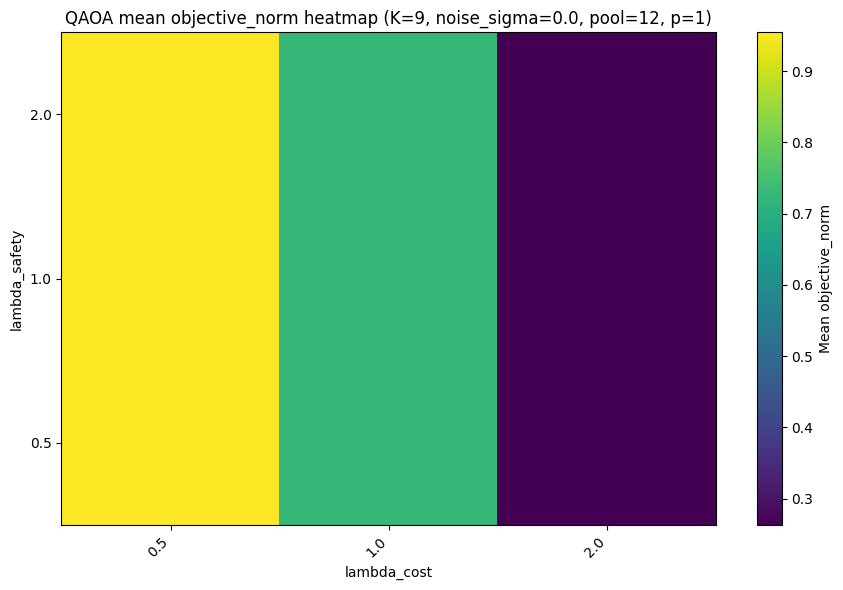

Saved: outputs/figures/05b_qaoa_objective_heatmap.png


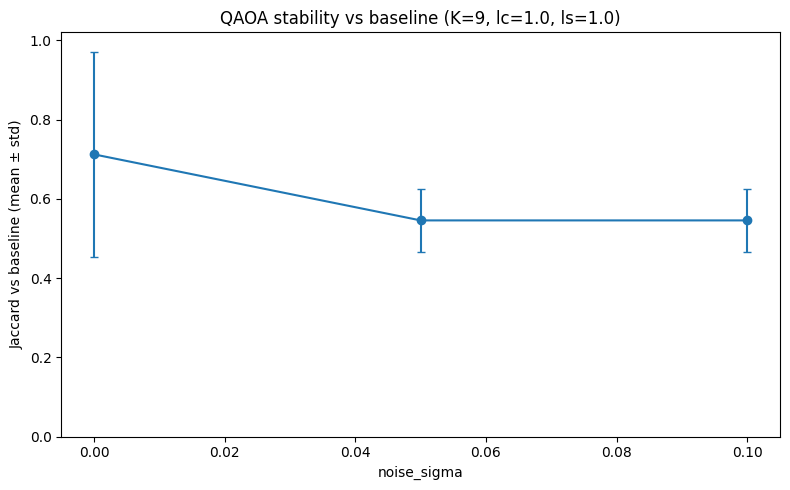

Saved: outputs/figures/05b_qaoa_jaccard_vs_baseline.png


In [10]:
# ============================================================
# Cell 5 — Visuals: objective heatmap + Jaccard stability plot
# ============================================================

# --- Heatmap slice (edit for readability) ---
# Pick a representative slice for a clean heatmap.
K_HEAT = K_values[len(K_values) // 2]
SIG_HEAT = 0.0

heat_slice = agg[(agg["K"] == K_HEAT) & (agg["noise_sigma"] == SIG_HEAT)].copy()
if heat_slice.empty:
    raise ValueError(f"No data for heatmap slice K={K_HEAT}, noise_sigma={SIG_HEAT}. Adjust K_HEAT/SIG_HEAT.")

pivot = (
    heat_slice.pivot(index="lambda_safety", columns="lambda_cost", values="objective_norm_mean")
              .sort_index(axis=0)
              .sort_index(axis=1)
)

plt.figure(figsize=(9, 6))
img = plt.imshow(pivot.values, aspect="auto", origin="lower")
plt.colorbar(img, label="Mean objective_norm")
plt.xticks(range(len(pivot.columns)), [str(x) for x in pivot.columns], rotation=45, ha="right")
plt.yticks(range(len(pivot.index)), [str(x) for x in pivot.index])
plt.xlabel("lambda_cost")
plt.ylabel("lambda_safety")
plt.title(f"QAOA mean objective_norm heatmap (K={K_HEAT}, noise_sigma={SIG_HEAT}, pool={POOL_SIZE}, p={P_LAYERS})")
plt.tight_layout()
plt.savefig(PATH_FIG_HEATMAP, dpi=160)
plt.show()

print("Saved:", PATH_FIG_HEATMAP)

# --- Jaccard vs noise plot for a single (K, lc, ls) slice (baseline λ and K) ---
K_LINE = BASELINE.K
LC_LINE = BASELINE.lambda_cost
LS_LINE = BASELINE.lambda_safety

line_slice = summary_df[
    (summary_df["K"] == K_LINE) &
    (summary_df["lambda_cost"] == LC_LINE) &
    (summary_df["lambda_safety"] == LS_LINE)
].copy()

if line_slice.empty:
    raise ValueError("No data for Jaccard line plot slice; adjust K_LINE/LC_LINE/LS_LINE.")

line_agg = (
    line_slice.groupby("noise_sigma", as_index=False)
              .agg(jaccard_mean=("jaccard_vs_baseline", "mean"),
                   jaccard_std=("jaccard_vs_baseline", "std"))
              .sort_values("noise_sigma")
)

plt.figure(figsize=(8, 5))
plt.errorbar(
    line_agg["noise_sigma"],
    line_agg["jaccard_mean"],
    yerr=line_agg["jaccard_std"],
    fmt="-o",
    capsize=3
)
plt.ylim(0, 1.02)
plt.xlabel("noise_sigma")
plt.ylabel("Jaccard vs baseline (mean ± std)")
plt.title(f"QAOA stability vs baseline (K={K_LINE}, lc={LC_LINE}, ls={LS_LINE})")
plt.tight_layout()
plt.savefig(PATH_FIG_JACCARD, dpi=160)
plt.show()

print("Saved:", PATH_FIG_JACCARD)


### What Cell 5 Just Did

- Created and saved an objective heatmap (mean normalized objective across λ_cost × λ_safety) for a chosen K/noise slice.
- Created and saved a stability plot showing how Jaccard similarity to the QAOA baseline changes as perturbation strength increases.
- These figures mirror the 05a outputs so 05a (greedy) vs 05b (QAOA) comparisons are straightforward.


In [11]:
# ============================================================
# Cell 6 — Wrap-up: previews, artifact list, and sanity checks
# ============================================================

print("Sweep summary preview:")
display(summary_df.head(10))

print("\nAggregated config preview (top by objective_norm_mean):")
display(agg.sort_values(["objective_norm_mean", "jaccard_mean"], ascending=[False, False]).head(10))

print("\nArtifacts written:")
print("  -", PATH_SWEEP_SUMMARY)
print("  -", PATH_TOP_TABLE)
print("  -", PATH_TOP_SELECTED)
print("  -", PATH_FIG_HEATMAP)
print("  -", PATH_FIG_JACCARD)

# --- Sanity checks ---
assert summary_df["selected_n"].min() >= 0
assert summary_df["selected_n"].max() <= max(K_values)
assert summary_df["objective_norm"].between(0, 1).all()

print("\nSanity checks passed.")


Sweep summary preview:


,config_id,K,lambda_cost,lambda_safety,noise_sigma,seed,pool_size,p,penalty_A,shots,...,best_energy,best_bitstring,gamma_0,beta_0,selected_n,total_benefit,total_cost,total_safety,objective,objective_norm
0,K6_lc0.5_ls0.5_sig0_seed0_pool12_p1_A10_sh128,6,0.5,0.5,0.00,0,12,1,10.0,128,...,2.400000,010001110101,0.20,0.2,6,3.600000,12.000000,0.0,-2.400000,0.985355
1,K6_lc0.5_ls0.5_sig0_seed1_pool12_p1_A10_sh128,6,0.5,0.5,0.00,1,12,1,10.0,128,...,2.400000,000111010101,0.20,0.2,6,3.600000,12.000000,0.0,-2.400000,0.985355
2,K6_lc0.5_ls0.5_sig0_seed2_pool12_p1_A10_sh128,6,0.5,0.5,0.00,2,12,1,10.0,128,...,2.400000,101010001011,0.20,0.2,6,3.600000,12.000000,0.0,-2.400000,0.985355
3,K6_lc0.5_ls0.5_sig0.05_seed0_pool12_p1_A10_sh128,6,0.5,0.5,0.05,0,12,1,10.0,128,...,2.110188,000001111101,0.20,0.2,6,3.661976,11.544327,0.0,-2.110188,0.992779
4,K6_lc0.5_ls0.5_sig0.05_seed1_pool12_p1_A10_sh128,6,0.5,0.5,0.05,1,12,1,10.0,128,...,2.205202,001010100111,0.55,1.6,6,3.685735,11.781875,0.0,-2.205202,0.990345
5,K6_lc0.5_ls0.5_sig0.05_seed2_pool12_p1_A10_sh128,6,0.5,0.5,0.05,2,12,1,10.0,128,...,2.227703,011010110010,0.20,0.2,6,3.713679,11.882764,0.0,-2.227703,0.989769
6,K6_lc0.5_ls0.5_sig0.1_seed0_pool12_p1_A10_sh128,6,0.5,0.5,0.10,0,12,1,10.0,128,...,1.828318,010001101101,1.60,0.2,6,3.723009,11.102654,0.0,-1.828318,1.000000
7,K6_lc0.5_ls0.5_sig0.1_seed1_pool12_p1_A10_sh128,6,0.5,0.5,0.10,1,12,1,10.0,128,...,2.010543,001010100111,0.55,1.6,6,3.773833,11.568753,0.0,-2.010543,0.995332
8,K6_lc0.5_ls0.5_sig0.1_seed2_pool12_p1_A10_sh128,6,0.5,0.5,0.10,2,12,1,10.0,128,...,2.015032,000011110011,1.25,0.9,6,3.800994,11.632052,0.0,-2.015032,0.995217
9,K6_lc0.5_ls1_sig0_seed0_pool12_p1_A10_sh128,6,0.5,1.0,0.00,0,12,1,10.0,128,...,2.400000,010001110101,0.20,0.2,6,3.600000,12.000000,0.0,-2.400000,0.985355



Aggregated config preview (top by objective_norm_mean):


,K,lambda_cost,lambda_safety,noise_sigma,pool_size,p,penalty_A,shots,objective_mean,objective_std,objective_norm_mean,jaccard_mean,jaccard_std,n_runs
2,6,0.5,0.5,0.10,12,1,10.0,128,-1.951298,0.106528,0.996850,0.363636,0.00000,3
5,6,0.5,1.0,0.10,12,1,10.0,128,-1.951298,0.106528,0.996850,0.363636,0.00000,3
8,6,0.5,2.0,0.10,12,1,10.0,128,-1.951298,0.106528,0.996850,0.363636,0.00000,3
1,6,0.5,0.5,0.05,12,1,10.0,128,-2.181031,0.062375,0.990965,0.409091,0.07873,3
4,6,0.5,1.0,0.05,12,1,10.0,128,-2.181031,0.062375,0.990965,0.409091,0.07873,3
7,6,0.5,2.0,0.05,12,1,10.0,128,-2.181031,0.062375,0.990965,0.409091,0.07873,3
0,6,0.5,0.5,0.00,12,1,10.0,128,-2.400000,0.000000,0.985355,0.409091,0.07873,3
3,6,0.5,1.0,0.00,12,1,10.0,128,-2.400000,0.000000,0.985355,0.409091,0.07873,3
6,6,0.5,2.0,0.00,12,1,10.0,128,-2.400000,0.000000,0.985355,0.409091,0.07873,3
29,9,0.5,0.5,0.10,12,1,10.0,128,-3.137273,0.144200,0.966469,0.545455,0.07873,3



Artifacts written:
  - data/results/05b_qaoa_robustness_sweep_summary.csv
  - data/results/05b_qaoa_top_config_table.csv
  - data/results/05b_qaoa_top_configs_selected_trials.csv
  - outputs/figures/05b_qaoa_objective_heatmap.png
  - outputs/figures/05b_qaoa_jaccard_vs_baseline.png

Sanity checks passed.


### What Cell 6 Just Did

- Displayed quick previews of the raw sweep results and the aggregated configuration table.
- Printed the exact output artifact paths created by the notebook.
- Ran basic sanity checks to confirm selection sizes and objective normalization behave as expected.


## Summary

This notebook produces a reproducible **QAOA (QUBO)** robustness sweep for Scenario A that:
- uses the same additive benefit/cost/safety-penalty contract as 05a,
- enforces an exact-K selection using a quadratic penalty,
- tests robustness under perturbations (`noise_sigma`, `seed`) and trade-off weights (λ),
- exports a sweep summary plus “top configs” selections,
- generates two presentation-ready figures (objective heatmap + stability plot),
- writes outputs under the `05b_qaoa_*` prefix to avoid collisions with other Phase 5 artifacts.

Recommended next step:
- Build **05c** to compare 05a vs 05b on objective/stability and overlap of selected trials across matched configurations.
